In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

In [2]:
emotion_dataset=load_dataset('dair-ai/emotion')

In [3]:
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']
label_names = emotion_dataset['train'].features['label'].names
test_text=emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [5]:
for i in train_label:
    print(label_names[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [6]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text' : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [7]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
df_train.tail()

,text,label
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger
15999,i know a lot but i feel so stupid because i ca...,sadness


In [9]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [10]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

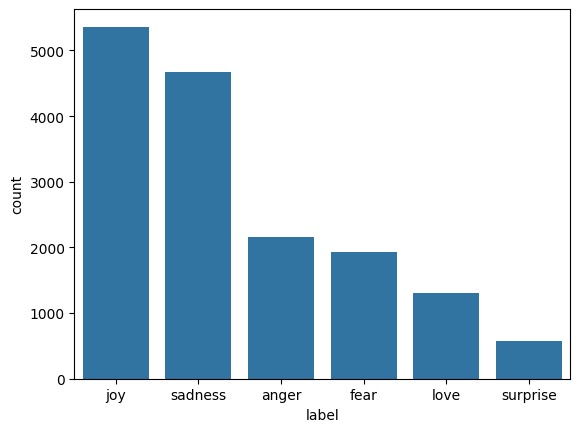

In [11]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [12]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

In [13]:
df_train.dtypes

text     object
label    object
dtype: object

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=15500

tokenizer=Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")
     

Vocabulary Size: 15213
Max Sentence Length: 50


In [29]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
     

/home/user/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.1631 - loss: 1.9378 - val_accuracy: 0.1810 - val_loss: 1.7883
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1643 - loss: 1.8071 - val_accuracy: 0.1130 - val_loss: 1.8006
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1609 - loss: 1.7835 - val_accuracy: 0.1105 - val_loss: 1.7941
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1698 - loss: 1.7634 - val_accuracy: 0.1620 - val_loss: 1.8092
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1810 - loss: 1.7883
RNN Loss: 1.7883127927780151
RNN Accuracy: 0.1809999942779541


In [33]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.1469 - loss: 1.7954 - val_accuracy: 0.0795 - val_loss: 1.7823
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1498 - loss: 1.7941 - val_accuracy: 0.0880 - val_loss: 1.7861
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1629 - loss: 1.7924 - val_accuracy: 0.3450 - val_loss: 1.7743
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1708 - loss: 1.7908 - val_accuracy: 0.1315 - val_loss: 1.8023
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.1620 - loss: 1.7663 - val_accuracy: 0.1345 - val_loss: 1.7967
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.2447 - loss: 1.5734 - val_accuracy: 0.2635 - val_loss: 1.5317
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.3364 - loss: 1.2838 - val_accuracy: 0.4170 - val_loss: 1.2402
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.5257 - loss: 1.0306 - 

In [34]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.1424 - loss: 1.7967 - val_accuracy: 0.3455 - val_loss: 1.7804
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.1491 - loss: 1.7948 - val_accuracy: 0.1380 - val_loss: 1.7685
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1593 - loss: 1.7945 - val_accuracy: 0.1200 - val_loss: 1.7753
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3455 - loss: 1.7804
GRU Loss: 1.7804415225982666
GRU Accuracy: 0.34549999237060547


In [35]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.390084,0.8900
2,GRU,1.780442,0.3455
0,RNN,1.788313,0.1810


In [43]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50, mask_zero=True),  # <-- added mask_zero=True
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20


E0000 00:00:1787839379.588525    8623 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 105ms/step - accuracy: 0.6344 - loss: 0.9063 - val_accuracy: 0.9065 - val_loss: 0.2343
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 108ms/step - accuracy: 0.9335 - loss: 0.1784 - val_accuracy: 0.9165 - val_loss: 0.2563
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - accuracy: 0.9550 - loss: 0.1160 - val_accuracy: 0.9170 - val_loss: 0.2113
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 124ms/step - accuracy: 0.9711 - loss: 0.0795 - val_accuracy: 0.9165 - val_loss: 0.2674
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 102ms/step - accuracy: 0.9793 - loss: 0.0541 - val_accuracy: 0.9190 - val_loss: 0.2666
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 103ms/step - accuracy: 0.9833 - loss: 0.0476 - val_accuracy: 0.9160 - val_loss: 0.2961


In [45]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")
     

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9170 - loss: 0.2113
BiGRU Loss: 0.21130426228046417
BiGRU Accuracy: 0.9169999957084656


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


<Axes: >

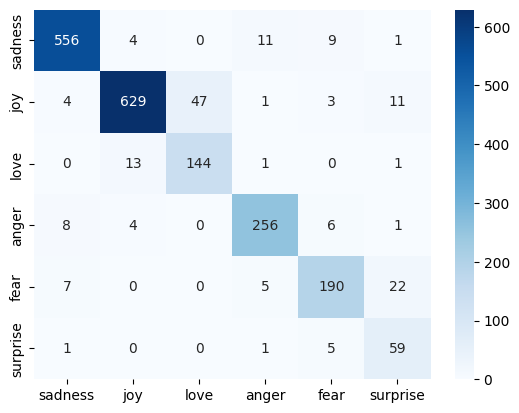

In [46]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)


In [47]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [48]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)